In [1]:
#1、导入库
import pandas as pd
import numpy as np
from scipy.optimize import brentq 
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib import rcParams

#调字体
rcParams['font.sans-serif'] = ['Microsoft YaHei']
rcParams['axes.unicode_minus'] = False

In [2]:
#2、债券定价：现金流贴现模型；债券风险指标
def bond_risk_metrics(face_value,coupon_rate,maturity,ytm,freq):
    n_periods=int(maturity * freq)
    coupon_payment=coupon_rate*face_value/freq
    cash_flows=[coupon_payment]*(n_periods-1)+[coupon_payment+face_value]
    y_period=ytm/freq
    times=np.array([(i+1)/freq for i in range(n_periods)])
    discount_factors = [(1 + y_period) ** (-(i + 1)) for i in range(n_periods)]
    pv_cf=np.array(cash_flows)*np.array(discount_factors)
    bond_price=np.sum(pv_cf)

    macaulay_duration=np.sum(times*pv_cf/bond_price)
    modified_duration=macaulay_duration/(1+y_period)
    convexity_numerator=np.sum(times*(times+1/freq)*pv_cf)
    convexity=convexity_numerator/(bond_price*(1+y_period)**2)
    dv01=bond_price*modified_duration*0.0001

    return{
    'price':bond_price,
    'macaulay_duration':macaulay_duration,
    'modified_duration':modified_duration,
    'convexity':convexity,
    'dv01':dv01
}
    

In [3]:
#3、导入数据
price_df=pd.read_excel('E:/python/数据/wind_bond_prices.xlsx', index_col=0)
price_df.index = pd.to_datetime(price_df.index)
bond_info = pd.read_excel('E:/python/数据/bond_basic.xlsx')  
print("=== Wind 原始数据 ===")
print(price_df.head())
print(f"\n数据形状: {price_df.shape}")
print(f"数据期间: {price_df.index[0].date()} 至 {price_df.index[-1].date()}")
print("\n=== 债券基础信息数据 ===")
print(bond_info)

#计算收益率,并描述性统计
returns_df = price_df.pct_change().dropna()
print("===日收益率===")
print(returns_df.head())
print(f"\n收益率统计:\n{returns_df.describe()}")

=== Wind 原始数据 ===
            230026.IB  240004.IB  240011.IB  230210.IB  240210.IB  230410.IB  \
Date                                                                           
2025-04-15   107.6528   105.1779   104.8503   107.6288   104.7270   107.5975   
2025-04-16   107.7895   105.3239   104.9266   107.7358   104.7897   107.7155   
2025-04-17   107.7313   105.3644   104.8735   107.7139   104.7245   107.7131   
2025-04-18   107.7067   105.2545   104.8972   107.6553   104.7420   107.7305   
2025-04-21   107.5977   105.1478   104.7388   107.6069   104.6089   107.7305   

            2405180.IB  
Date                    
2025-04-15    103.1157  
2025-04-16    103.1157  
2025-04-17    103.1157  
2025-04-18    103.1157  
2025-04-21    103.1157  

数据形状: (243, 7)
数据期间: 2025-04-15 至 2026-04-15

=== 债券基础信息数据 ===
    bond_code valuation_date  face_value       ytm  coupon_rate maturity_date  \
0  2405180.IB     2026-04-15        4000  2.329973         2.68    2054-03-28   
1   230410.IB     20

In [4]:
#4、计算估值日久期、DV01
bond_info['valuation_date'] = pd.to_datetime(bond_info['valuation_date'])
bond_info['maturity_date'] = pd.to_datetime(bond_info['maturity_date'])
bond_info['T_remaining'] = (bond_info['maturity_date'] - bond_info['valuation_date']).dt.days / 365.0
bond_info['T_remaining'] = bond_info['T_remaining'].clip(lower=0)  # 避免负值
bond_info['ytm'] = bond_info['ytm'] / 100.0
bond_info['coupon_rate'] = bond_info['coupon_rate'] / 100.0

#_批量计算每只债券的风险指标
def apply_metrics(row):
    m = bond_risk_metrics(
        face_value=row['face_value'],
        coupon_rate=row['coupon_rate'],
        maturity=row['T_remaining'],
        ytm=row['ytm'],
        freq=row['freq']
    )
    return pd.Series({
        'price': m['price'],
        'macaulay_duration': m['macaulay_duration'],
        'modified_duration': m['modified_duration'],
        'dv01': m['dv01'],
        'convexity': m['convexity']
    })

bond_info[['price','macaulay_duration', 'modified_duration', 'dv01', 'convexity']] = bond_info.apply(apply_metrics, axis=1)

# _计算组合汇总
total_face = bond_info['face_value'].sum()
total_dv01 = bond_info['dv01'].sum()
weighted_duration = (bond_info['modified_duration'] * bond_info['face_value']).sum() / total_face

print("=== 组合风险指标（估值日自主计算）===")
print(f"估值日期: {bond_info['valuation_date'].iloc[0].strftime('%Y-%m-%d')}")
print(f"组合总面值: {total_face:,.0f} 万元")
print(f"组合加权修正久期: {weighted_duration:.2f} 年")
print(f"组合总 DV01: {total_dv01:.2f} 万元")
print("\n单券明细：")
print(bond_info[['bond_code', 'macaulay_duration', 'modified_duration', 'dv01', 'price']].head())


=== 组合风险指标（估值日自主计算）===
估值日期: 2026-04-15
组合总面值: 42,000 万元
组合加权修正久期: 8.07 年
组合总 DV01: 35.95 万元

单券明细：
    bond_code  macaulay_duration  modified_duration      dv01        price
0  2405180.IB          19.933974          19.704420  8.439632  4283.115928
1   230410.IB           6.469197           6.356059  3.395833  5342.671447
2   240210.IB           7.400193           7.268880  3.024285  4160.592458
3   230210.IB           6.470859           6.358036  4.075202  6409.530364
4   240011.IB           7.377212           7.315252  6.103404  8343.396055


In [5]:
#5、基于历史模拟法计算VaR、ES
def calculate_portfolio_var(positions,historical_returns,confidence=0.95):
    total_position = sum(positions)
    weights = np.array(positions)/total_position
    portfolio_returns = historical_returns @ weights
    var_percentile = (1-confidence) * 100
    var = np.percentile(portfolio_returns, var_percentile)
    es = portfolio_returns[portfolio_returns <= var].mean()

    return{
        'VaR':var,
        'ES':es,
        'confidence':confidence,
        'portfolio_return':portfolio_returns,
        'total_notional':total_position
    }

#——给持仓，用历史收盘价计算VAR
positions = bond_info['face_value']
result = calculate_portfolio_var(positions, returns_df, confidence=0.95)
print(f"\n=== 组合风险指标（Wind真实数据）===")
print(f"数据期间: {returns_df.index[0].date()} 至 {returns_df.index[-1].date()}")
print(f"观测天数: {len(returns_df)}")
print(f"组合名义本金: {result['total_notional']:.0f}万元")
print(f"95% VaR: {result['VaR']:.4%} ({abs(result['VaR'])*result['total_notional']:.0f}万元)")
print(f"95% ES: {result['ES']:.4%} ({abs(result['ES'])*result['total_notional']:.0f}万元)")


=== 组合风险指标（Wind真实数据）===
数据期间: 2025-04-16 至 2026-04-15
观测天数: 242
组合名义本金: 42000万元
95% VaR: -0.1238% (52万元)
95% ES: -0.2738% (115万元)


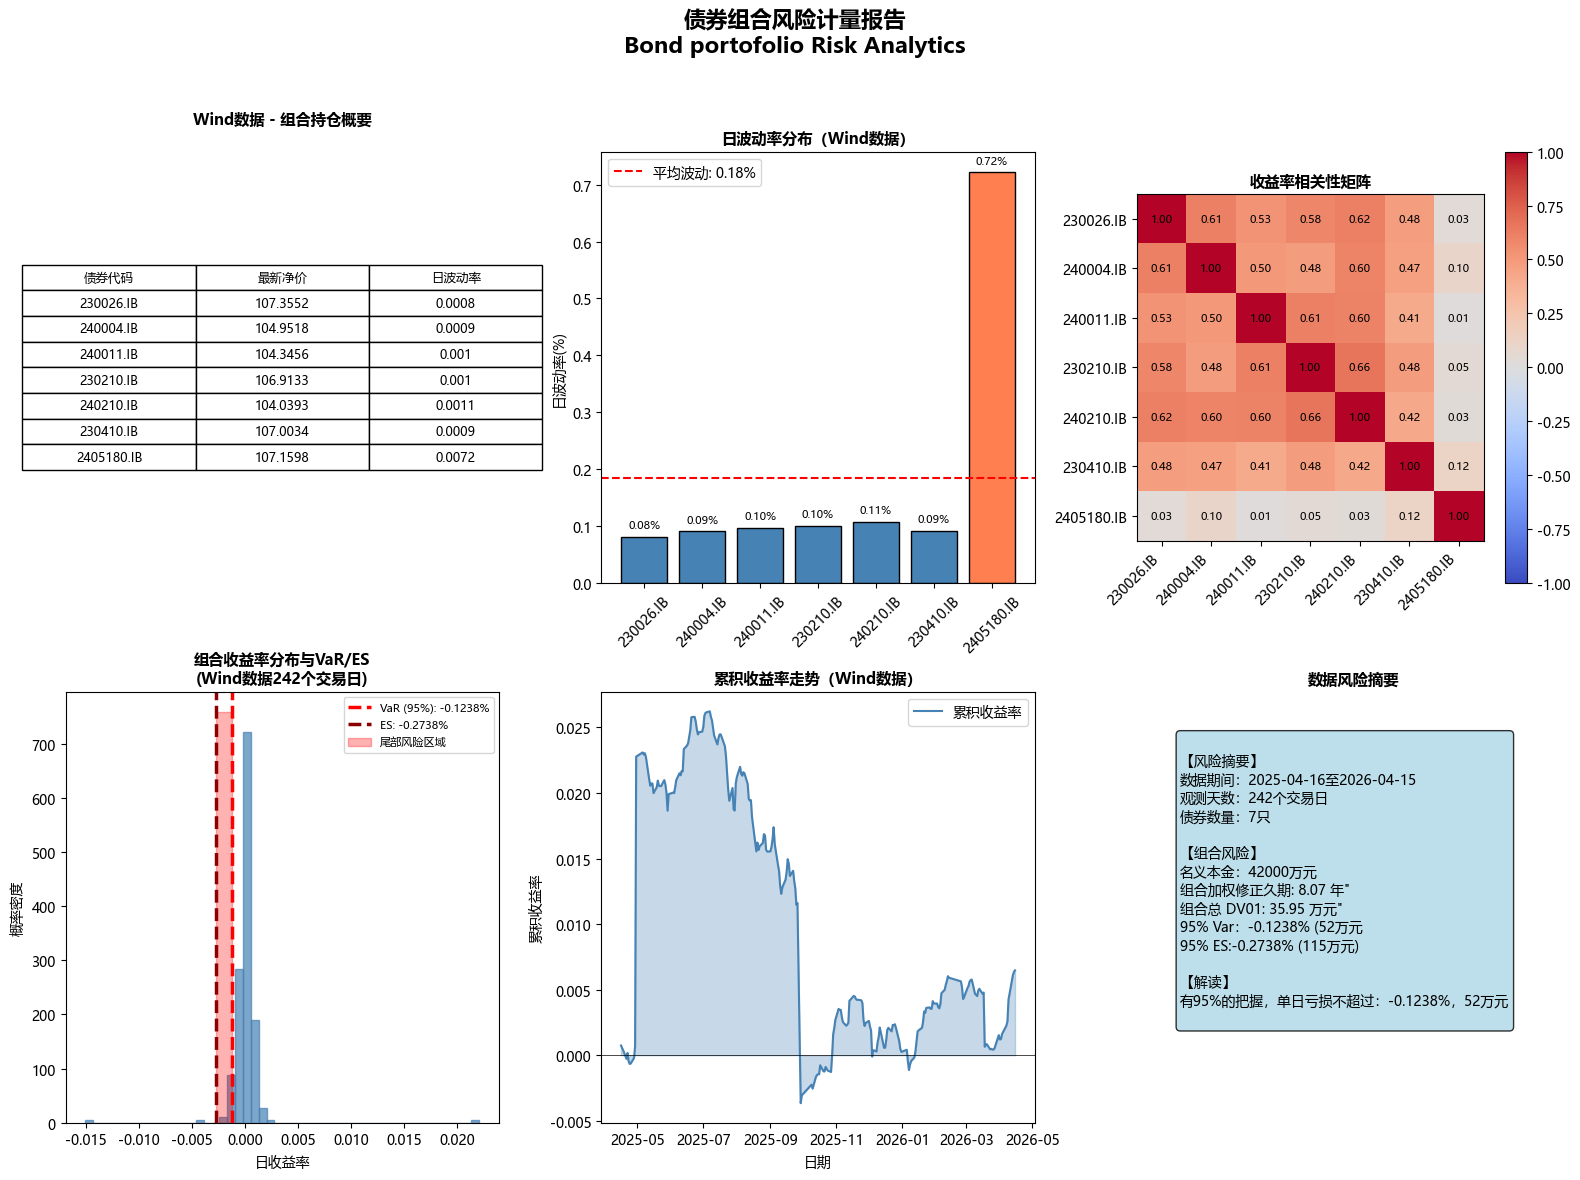


✅ 报告已保存: 债券组合风险报告.png


In [10]:
#6、画图 
#——建立画布
fig = plt.figure(figsize=(16,12))
fig.suptitle('债券组合风险计量报告\nBond portofolio Risk Analytics',fontsize=16, fontweight='bold',y=0.98)

#图1 组合持仓摘要表
ax1 = plt.subplot(2, 3, 1)
ax1.axis('off')
latest_prices = price_df.iloc[-1]
summary_data = pd.DataFrame({
    '债券代码': returns_df.columns,
    '最新净价': latest_prices.values.round(4),
    '日波动率': returns_df.std().values.round(4)
})
table = ax1.table(cellText=summary_data.values,
                 colLabels=summary_data.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)#按比例缩放表格的单元格尺寸。
ax1.set_title('Wind数据 - 组合持仓概要', fontsize=11, fontweight='bold', pad=20)

#图2：单券波动率对比[柱形图]
ax2 = plt.subplot(2,3,2)
vols = returns_df.std() * 100 
colors = ['steelblue' if v < vols.mean() else 'coral' for v in vols]
bars = ax2.bar(returns_df.columns, vols, color=colors, edgecolor='black')
ax2.axhline(vols.mean(), color='red', linestyle='--', label=f'平均波动: {vols.mean():.2f}%')
ax2.set_title('日波动率分布（Wind数据）', fontsize=11, fontweight='bold')
ax2.set_ylabel('日波动率(%)')
ax2.tick_params(axis='x', rotation=45)#设置X坐标的刻度线、刻度标签的参数。
ax2.legend()#在 ax2 子图上显示图例。
for bar, val in zip(bars,vols):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,
            f'{val:.2f}%', ha='center', va='bottom',fontsize=8)
    
#图3 收益率相关性热力图
ax3 = plt.subplot(2,3,3)
corr_matrix = returns_df.corr()
im = ax3.imshow(corr_matrix, cmap = 'coolwarm', vmin = -1, vmax = 1)
ax3.set_xticks(range(len(corr_matrix)))
ax3.set_yticks(range(len(corr_matrix)))
ax3.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax3.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = ax3.text(j,i,f'{corr_matrix.iloc[i,j]:.2f}',
                    ha="center", va="center",color="black", fontsize=8)
plt.colorbar(im, ax=ax3)    
ax3.set_title('收益率相关性矩阵', fontsize=11, fontweight='bold')

# 图4：组合收益率分布与VaR/ES分布直方图【看概率密度】
ax4 = plt.subplot(2, 3, 4)
ax4.hist(result['portfolio_return'],bins=50,
         alpha=0.7,color='steelblue',edgecolor='steelblue',density=True)
ax4.axvline(result['VaR'], color='red', linestyle='--', linewidth=2.5,
            label=f'VaR (95%): {result["VaR"]:.4%}')
ax4.axvline(result['ES'], color='darkred', linestyle='--', linewidth=2.5,
            label=f'ES: {result["ES"]:.4%}')
ax4.fill_betweenx([0, ax4.get_ylim()[1]], result['VaR'], result['ES'], 
                  alpha=0.3, color='red', label='尾部风险区域')
ax4.set_title(f'组合收益率分布与VaR/ES\n(Wind数据{len(returns_df)}个交易日)', 
              fontsize=11, fontweight='bold')
ax4.set_xlabel('日收益率')
ax4.set_ylabel('概率密度')
ax4.legend(fontsize=8)

# 图5：累积收益走势[折线图]
ax5 = plt.subplot(2,3,5)
if isinstance(result['portfolio_return'], pd.Series):
    dates = result['portfolio_return'].index
    cumulative = (1 + result['portfolio_return']).cumprod() - 1
else:
    # 如果已经是数组，则用 returns_df 的索引重建
    dates = returns_df.index
    cumulative = (1 + result['portfolio_return']).cumprod() - 1
    cumulative = pd.Series(cumulative, index=dates)
    
dates = returns_df.index
ax5.plot(dates, cumulative, color='steelblue', linewidth=1.5, label='累积收益率')
ax5.fill_between(dates, 0, cumulative, alpha=0.3, color='steelblue')
ax5.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax5.set_title('累积收益率走势（Wind数据）', fontsize=11, fontweight='bold')
ax5.set_xlabel('日期')
ax5.set_ylabel('累积收益率')
ax5.legend()

# 图6：摘要
ax6 = plt.subplot(2,3,6)
ax6.axis('off')
summary_text = f"""
【风险摘要】
数据期间：{returns_df.index[0].date()}至{returns_df.index[-1].date()}
观测天数：{len(returns_df)}个交易日
债券数量：{len(returns_df.columns)}只

【组合风险】
名义本金：{result['total_notional']:.0f}万元
组合加权修正久期: {weighted_duration:.2f} 年"
组合总 DV01: {total_dv01:.2f} 万元"
95% Var：{result['VaR']:.4%} ({abs(result['VaR'])*result['total_notional']:.0f}万元
95% ES:{result['ES']:.4%} ({abs(result['ES'])*result['total_notional']:.0f}万元)

【解读】
有95%的把握，单日亏损不超过：{result['VaR']:.4%}，{abs(result['VaR'])*result['total_notional']:.0f}万元
"""
ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
ax6.set_title('数据风险摘要', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('债券组合风险报告.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ 报告已保存: 债券组合风险报告.png")

In [8]:
#7、风险摘要【excel】
summary_data = {
    '指标': [
        '估值日期', 
        '组合面值(万元)', 
        '加权修正久期(年)', 
        '组合DV01(万元)', 
        f'{int(0.95*100)}% 日VaR(万元)',
        f'{int(0.95*100)}% ES(万元)',
        'VaR 置信水平'
    ],
    '数值': [
        bond_info['valuation_date'].iloc[0].strftime('%Y-%m-%d'),
        f"{result['total_notional']:.2f}",
        f"{weighted_duration:.2f}",
        f"{total_dv01:.2f}",
        f"{abs(result['VaR'])*result['total_notional']:.2f}万元",
        f"{abs(result['ES'])*result['total_notional']:.2f}万元",
        f"{int(0.95*100)}%"
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_excel('bond_risk_summary.xlsx', index=False)
print("风险摘要已导出为 bond_risk_summary.xlsx")

风险摘要已导出为 bond_risk_summary.xlsx
